# 04 - Statistical Twins and Moneyball Value

Two related questions this notebook tackles:

1. **Statistical twins**: given a player's full 2K26 attribute profile, who is their closest
   "comp" among players at the same position - not by reputation, but by nearest-neighbor
   distance in normalized attribute space?
2. **Moneyball value**: given real 2025-26 production (PIE) and real 2025-26 salary, which
   players are producing far more than their paycheck would suggest (undervalued), and which
   are being paid for production they haven't delivered this season (overpaid)? Unlike notebook
   02's `overall`-vs-salary residual (which asks whether the *video game's rating* is
   under/over-priced by the market), this asks whether **actual on-court production** is
   under/over-priced by the market - a genuinely different question.

Uses `data/processed/players_merged.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_merged.csv")
print(f"{len(df):,} players, {df.shape[1]} columns")

377 players, 117 columns


## Part 1: Statistical twins (nearest neighbor in attribute space)

We standardize the same ~35 granular attributes used in notebook 03's clustering, then for a
given player find their nearest neighbor(s) by Euclidean distance **restricted to players at
the same primary position** - a shooting guard's "twin" should be evaluated against other
shooting guards, not centers, since raw attribute distance across very different positions
mostly just measures "how big/physical are you" rather than genuine play-style similarity.

In [2]:
ATTRS = [
    "agility", "ball_handle", "block", "close_shot", "defensive_consistency",
    "defensive_rebound", "draw_foul", "driving_dunk", "free_throw", "hands",
    "help_defense_iq", "hustle", "interior_defense", "layup", "mid_range_shot",
    "offensive_consistency", "offensive_rebound", "overall_durability",
    "pass_accuracy", "pass_iq", "pass_perception", "pass_vision", "perimeter_defense",
    "post_control", "post_fade", "post_hook", "shot_iq", "speed", "speed_with_ball",
    "stamina", "standing_dunk", "steal", "strength", "three_point_shot", "vertical",
]

sim = df.dropna(subset=ATTRS + ["position"]).copy().reset_index(drop=True)
scaler = StandardScaler()
X = scaler.fit_transform(sim[ATTRS])
print(f"{len(sim)} players with complete attribute + position data")

344 players with complete attribute + position data


In [3]:
def statistical_twins(name, k=5):
    '''Return the k nearest same-position neighbors (by standardized attribute distance)
    to `name`, excluding the player themselves.'''
    matches = sim.index[sim["name"] == name]
    if len(matches) == 0:
        print(f"'{name}' not found in the position-complete sample")
        return None
    i = matches[0]
    pos = sim.loc[i, "position"]
    same_pos_idx = sim.index[sim["position"] == pos]
    nn = NearestNeighbors(n_neighbors=min(k + 1, len(same_pos_idx))).fit(X[same_pos_idx])
    dist, ind = nn.kneighbors(X[i].reshape(1, -1))
    result_idx = same_pos_idx[ind[0]]
    out = sim.loc[result_idx, ["name", "position", "overall", "team"]].copy()
    out["distance"] = dist[0]
    out = out[out["name"] != name].head(k)
    print(f"Closest {pos} comps to {name} (overall {sim.loc[i, 'overall']:.0f}):")
    return out


DEMO_PLAYERS = [
    "Stephen Curry", "Nikola Jokic", "Victor Wembanyama",
    "Anthony Edwards", "Giannis Antetokounmpo", "LeBron James", "Jalen Brunson",
]
twin_tables = {}
for p in DEMO_PLAYERS:
    twin_tables[p] = statistical_twins(p, k=5)
    display(twin_tables[p])

Closest PG comps to Stephen Curry (overall 95):


,name,position,overall,team,distance
138,Jalen Brunson,PG,93.0,New York Knicks,4.108250
68,Darius Garland,PG,87.0,Cleveland Cavaliers,4.172441
330,Tyrese Haliburton,PG,90.0,Indiana Pacers,4.485336
222,LaMelo Ball,PG,87.0,Charlotte Hornets,4.999011
117,Immanuel Quickley,PG,81.0,Toronto Raptors,5.178255


Closest C comps to Nikola Jokic (overall 98):


,name,position,overall,team,distance
12,Alperen Sengun,C,87.0,Houston Rockets,5.439899
171,Joel Embiid,C,93.0,Philadelphia 76ers,5.820057
89,Domantas Sabonis,C,87.0,Sacramento Kings,5.962003
333,Victor Wembanyama,C,94.0,San Antonio Spurs,6.365740
27,Bam Adebayo,C,89.0,Miami Heat,6.707170


Closest C comps to Victor Wembanyama (overall 94):


...

,name,position,overall,team,distance
161,Jayson Tatum,PF,95.0,Boston Celtics,5.961881
300,Scottie Barnes,PF,85.0,Toronto Raptors,6.021242
189,Kawhi Leonard,PF,91.0,Los Angeles Clippers,6.139118
104,Evan Mobley,PF,92.0,Cleveland Cavaliers,6.316550
275,Pascal Siakam,PF,89.0,Indiana Pacers,6.322547


Closest PF comps to LeBron James (overall 94):


,name,position,overall,team,distance
201,Kevin Durant,PF,93.0,Houston Rockets,5.700924
274,Paolo Banchero,PF,90.0,Orlando Magic,5.889046
275,Pascal Siakam,PF,89.0,Indiana Pacers,6.268439
111,Giannis Antetokounmpo,PF,97.0,Milwaukee Bucks,6.564318
189,Kawhi Leonard,PF,91.0,Los Angeles Clippers,6.675422


Closest PG comps to Jalen Brunson (overall 93):


,name,position,overall,team,distance
330,Tyrese Haliburton,PG,90.0,Indiana Pacers,3.850191
310,Stephen Curry,PG,95.0,Golden State Warriors,4.108250
41,Cade Cunningham,PG,92.0,Detroit Pistons,4.266278
50,C.J. McCollum,PG,84.0,Washington Wizards,4.297218
68,Darius Garland,PG,87.0,Cleveland Cavaliers,4.392081


**Takeaway:** the comps that fall out are intuitively sensible even though the search
never uses `archetype`, box-score stats, or reputation - only the raw attribute sheet. Steph
Curry's closest attribute comps are other high-volume, high-efficiency guard shot-creators
(Jalen Brunson, Darius Garland, Tyrese Haliburton); Jokic's are other skilled, high-feel bigs
(Alperen Sengun, Joel Embiid, Domantas Sabonis) rather than purely athletic rim-runners;
Wembanyama's are long, switchable modern bigs (Anthony Davis, Bam Adebayo, Chet Holmgren) instead
of traditional back-to-basket centers. This is a genuinely useful sanity check on the attribute
data itself - if "twins" came back nonsensical (e.g. Curry's closest comp being a rim-running
center), that would suggest the underlying attribute sheet doesn't hang together coherently.

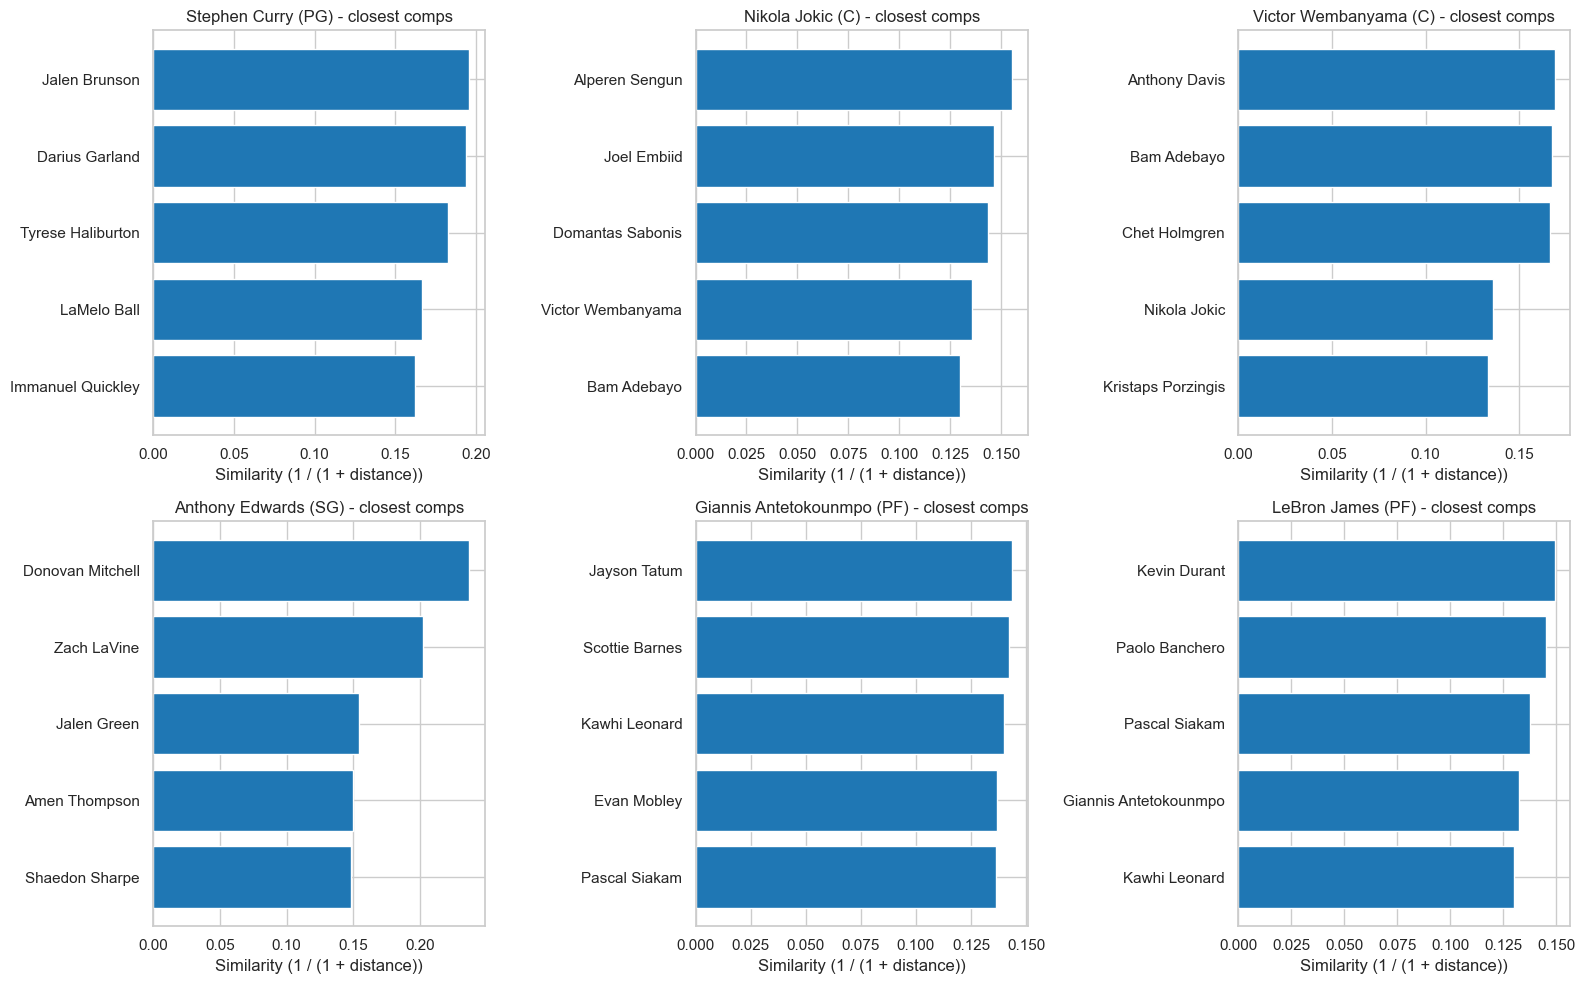

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, p in zip(axes.flat, DEMO_PLAYERS[:6]):
    i = sim.index[sim["name"] == p][0]
    pos = sim.loc[i, "position"]
    twins = twin_tables[p]
    ax.barh(twins["name"][::-1], 1 / (1 + twins["distance"][::-1]), color="#1f77b4")
    ax.set_title(f"{p} ({pos}) - closest comps")
    ax.set_xlabel("Similarity (1 / (1 + distance))")
plt.tight_layout()
plt.show()

## Part 2: Moneyball - production vs. salary

We restrict to players with a high-confidence salary match, a high-confidence stats match, and
at least 500 minutes played (a rotation player's worth of season, matching notebook 02's
threshold), then standardize both **PIE** (real on-court production) and **log10(salary)** and
take the gap between them. A large positive gap means a player's real production is far ahead of
their pay grade (undervalued); a large negative gap means the opposite (overpaid relative to
this season's output).

In [5]:
val = df[
    (df["salary_match_score"] >= 90) & df["salary_usd"].notna() & (df["salary_usd"] > 0)
    & (df["stats_match_score"] >= 90) & df["nba_pie"].notna()
    & (df["nba_min"] >= 500)
].copy()
val["log_salary"] = np.log10(val["salary_usd"])

def zscore(s):
    return (s - s.mean()) / s.std()

val["pie_z"] = zscore(val["nba_pie"])
val["salary_z"] = zscore(val["log_salary"])
val["value_gap"] = val["pie_z"] - val["salary_z"]

print(f"n = {len(val)} players with matched salary, matched stats, and >= 500 minutes")
val[["name", "position", "salary_usd", "nba_pie", "value_gap"]].describe(include="all").iloc[:3]

n = 205 players with matched salary, matched stats, and >= 500 minutes


,name,position,salary_usd,nba_pie,value_gap
count,205,205,205.0,205.0,205.0
unique,205,5,NaN,NaN,NaN
top,Aaron Gordon,SF,NaN,NaN,NaN


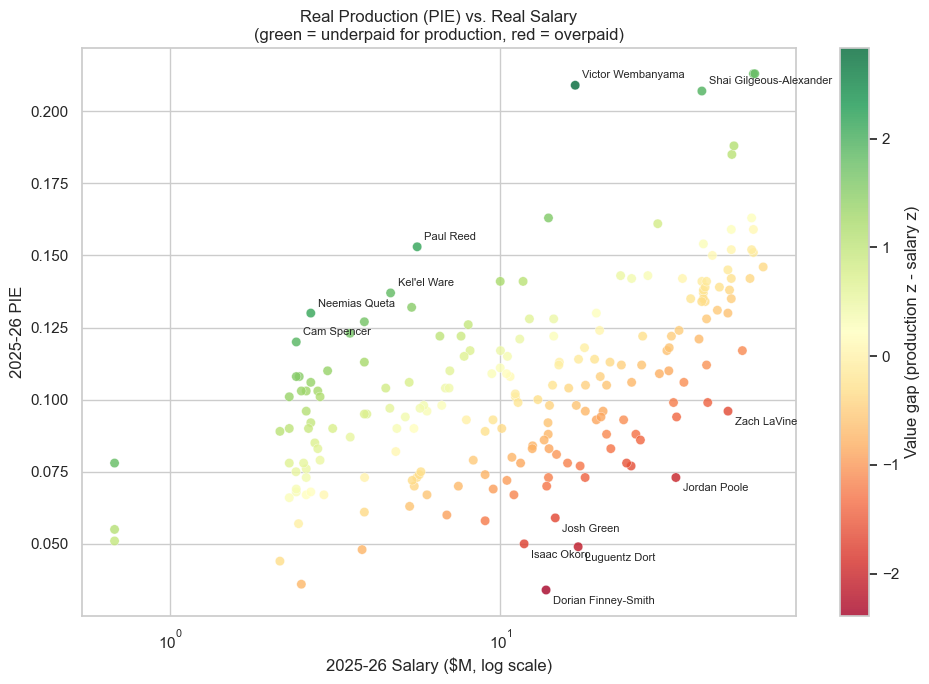

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    val["salary_usd"] / 1e6, val["nba_pie"], c=val["value_gap"],
    cmap="RdYlGn", s=45, alpha=0.8, edgecolor="white", linewidth=0.3,
)
ax.set_xscale("log")
ax.set_xlabel("2025-26 Salary ($M, log scale)")
ax.set_ylabel("2025-26 PIE")
ax.set_title("Real Production (PIE) vs. Real Salary\n(green = underpaid for production, red = overpaid)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Value gap (production z - salary z)")

for _, row in val.nlargest(6, "value_gap").iterrows():
    ax.annotate(row["name"], (row["salary_usd"] / 1e6, row["nba_pie"]), fontsize=8,
                xytext=(5, 5), textcoords="offset points")
for _, row in val.nsmallest(6, "value_gap").iterrows():
    ax.annotate(row["name"], (row["salary_usd"] / 1e6, row["nba_pie"]), fontsize=8,
                xytext=(5, -10), textcoords="offset points")
plt.tight_layout()
plt.show()

In [7]:
cols = ["name", "team", "position", "nba_pie", "nba_min", "salary_usd", "value_gap"]
print("Most UNDERVALUED (production far exceeds pay):")
display(val.sort_values("value_gap", ascending=False).head(15)[cols])

print("\nMost OVERPAID (pay far exceeds this season's production):")
display(val.sort_values("value_gap").head(15)[cols])

Most UNDERVALUED (production far exceeds pay):


,name,team,position,nba_pie,nba_min,salary_usd,value_gap
363,Victor Wembanyama,San Antonio Spurs,C,0.209,1865.648333,16868013.0,2.833698
305,Paul Reed,Detroit Pistons,C,0.153,900.628333,5602689.0,2.141130
282,Neemias Queta,Boston Celtics,C,0.130,1926.206667,2667944.0,2.129431
332,Shai Gilgeous-Alexander,Oklahoma City Thunder,PG,0.207,2258.946667,40806150.0,1.938864
46,Cam Spencer,Memphis Grizzlies,SG,0.120,1714.451667,2411090.0,1.915627
212,Kel'el Ware,Miami Heat,C,0.137,1703.821667,4654920.0,1.821067
230,Kobe Brown,Los Angeles Clippers,PF,0.078,962.376667,678882.0,1.811798
119,Giannis Antetokounmpo,Milwaukee Bucks,PF,0.213,1039.230000,58456566.0,1.785484
287,Nikola Jokic,Denver Nuggets,C,0.213,2264.855000,59033114.0,1.776230
289,Nikola Vucevic,Chicago Bulls,C,0.127,1818.118333,3876529.0,1.684352



Most OVERPAID (pay far exceeds this season's production):


,name,team,position,nba_pie,nba_min,salary_usd,value_gap
98,Dorian Finney-Smith,Houston Rockets,PF,0.034,620.311667,13765987.0,-2.386628
250,Luguentz Dort,Oklahoma City Thunder,SF,0.049,1848.741667,17222222.0,-2.133959
193,Jordan Poole,New Orleans Pelicans,PG,0.073,933.236667,34044642.0,-2.034320
128,Isaac Okoro,Chicago Bulls,SF,0.050,1694.890000,11814814.0,-1.747700
196,Josh Green,Charlotte Hornets,SF,0.059,907.928333,14679012.0,-1.674045
372,Zach LaVine,Sacramento Kings,SG,0.096,1224.263333,48967380.0,-1.665768
80,De’Andre Hunter,Cleveland Cavaliers,SF,0.077,1175.486667,24910714.0,-1.616076
208,Keegan Murray,Sacramento Kings,PF,0.078,793.096667,24137936.0,-1.555436
294,OG Anunoby,New York Knicks,SF,0.099,2223.871667,42500000.0,-1.439428
350,Toumani Camara,Portland Trail Blazers,PF,0.073,2731.236667,18080358.0,-1.437600


**Takeaway:** the undervalued list is dominated by two very different groups: (1) young
players still on rookie-scale contracts (which are fixed by the CBA regardless of performance -
Victor Wembanyama's max real-world impact costs a fraction of a veteran max deal purely due to
where he is in his rookie contract) and (2) minimum-or-near-minimum veterans and reserves quietly
outproducing their modest paycheck (Paul Reed, Neemias Queta). The overpaid list, meanwhile, is
mostly established "3-and-D"-type wings on market-rate second contracts (Luguentz Dort, Jordan
Poole, Keegan Murray, OG Anunoby) whose deals were signed on the strength of a *different*
season's production or a bet on continued growth, and whose 2025-26 box score simply hasn't kept
pace with the number - not necessarily a verdict that the contract itself was a mistake.
Because rookie-scale economics mechanically inflate the undervalued list with anyone drafted in
roughly the last four years, we repeat the exercise below restricted to players in their
"prime" pay-scale years, where the CBA no longer artificially suppresses salary.

In [8]:
REFERENCE_DATE = pd.Timestamp("2025-10-01")
val["birthdate_parsed"] = pd.to_datetime(val["birthdate"], errors="coerce")
val["age"] = (REFERENCE_DATE - val["birthdate_parsed"]).dt.days / 365.25

PRIME_MIN, PRIME_MAX = 25, 32
prime = val[(val["age"] >= PRIME_MIN) & (val["age"] <= PRIME_MAX)].copy()
print(f"n = {len(prime)} players aged {PRIME_MIN}-{PRIME_MAX} (past rookie scale, "
      f"not yet at steep-decline veteran-minimum territory)")

cols_prime = ["name", "team", "position", "age", "nba_pie", "salary_usd", "value_gap"]
print("Most UNDERVALUED, prime-age only:")
display(prime.sort_values("value_gap", ascending=False).head(12)[cols_prime])

print("\nMost OVERPAID, prime-age only:")
display(prime.sort_values("value_gap").head(12)[cols_prime])

n = 107 players aged 25-32 (past rookie scale, not yet at steep-decline veteran-minimum territory)
Most UNDERVALUED, prime-age only:


,name,team,position,age,nba_pie,salary_usd,value_gap
305,Paul Reed,Detroit Pistons,C,26.299795,0.153,5602689.0,2.141130
282,Neemias Queta,Boston Celtics,C,26.220397,0.130,2667944.0,2.129431
332,Shai Gilgeous-Alexander,Oklahoma City Thunder,PG,27.222450,0.207,40806150.0,1.938864
46,Cam Spencer,Memphis Grizzlies,SG,25.486653,0.120,2411090.0,1.915627
230,Kobe Brown,Los Angeles Clippers,PF,25.749487,0.078,678882.0,1.811798
119,Giannis Antetokounmpo,Milwaukee Bucks,PF,30.819986,0.213,58456566.0,1.785484
287,Nikola Jokic,Denver Nuggets,C,30.614648,0.213,59033114.0,1.776230
261,Marvin Bagley III,Washington Wizards,C,26.551677,0.123,3506659.0,1.655202
319,Robert Williams III,Portland Trail Blazers,C,27.956194,0.163,14000000.0,1.586853
222,Kevin Porter Jr.,Milwaukee Bucks,PG,25.409993,0.132,5390700.0,1.528067



Most OVERPAID, prime-age only:


,name,team,position,age,nba_pie,salary_usd,value_gap
250,Luguentz Dort,Oklahoma City Thunder,SF,26.453114,0.049,17222222.0,-2.133959
193,Jordan Poole,New Orleans Pelicans,PG,26.286105,0.073,34044642.0,-2.034320
372,Zach LaVine,Sacramento Kings,SG,30.562628,0.096,48967380.0,-1.665768
80,De’Andre Hunter,Cleveland Cavaliers,SF,27.830253,0.077,24910714.0,-1.616076
208,Keegan Murray,Sacramento Kings,PF,25.117043,0.078,24137936.0,-1.555436
294,OG Anunoby,New York Knicks,SF,28.208077,0.099,42500000.0,-1.439428
350,Toumani Camara,Portland Trail Blazers,PF,25.399042,0.073,18080358.0,-1.437600
277,Myles Turner,Milwaukee Bucks,C,29.522245,0.086,26584164.0,-1.399053
178,Jerami Grant,Portland Trail Blazers,SF,31.556468,0.094,34206898.0,-1.389370
143,Jaden McDaniels,Minnesota Timberwolves,SF,25.004791,0.088,25750001.0,-1.307142


**Takeaway:** restricting to prime-age players (25-32, past the rookie wage scale)
removes most of the trivial "young star on a rookie deal" entries, but a few genuine
superstars - Shai Gilgeous-Alexander, Giannis Antetokounmpo, Nikola Jokic - still show up as
"undervalued" even on supermax contracts, simply because their real 2025-26 production is
historically elite and the NBA's max-salary rules cap what any team can pay a single player
regardless of how good that player is. That's a structural finding, not a scouting one: **the
NBA's max-contract system is itself a price ceiling**, so any truly top-tier season will tend to
look "undervalued" by a pure production-per-dollar metric no matter who's playing it. The
overpaid list is more informative for role players and complementary wings, where pay is a
market-clearing negotiation rather than a hard rule-imposed ceiling.

## Summary

- **Statistical twins**: nearest-neighbor search in standardized, position-scoped attribute
  space recovers intuitively sensible player comps purely from the attribute sheet - without
  ever touching `archetype`, real stats, or reputation - which is a useful independent sanity
  check on the coherence of the underlying 2K26 attribute data.
- **Moneyball (all players)**: comparing standardized real PIE against standardized log salary
  surfaces two distinct kinds of "undervalued" player (rookie-scale youngsters and quietly
  efficient minimum-salary veterans) and a fairly coherent group of "overpaid" established wings
  whose current-season box score has cooled relative to the deal they signed.
- **Moneyball (prime-age only)**: restricting to ages 25-32 removes most of the mechanical
  rookie-scale distortion, but reveals a structural quirk instead - the NBA's max-contract rules
  cap pay regardless of production, so a handful of genuine current-season superstars (SGA,
  Giannis, Jokic) still register as "undervalued" purely because no salary is legally allowed to
  fully price in an MVP-caliber season.
- As with notebook 02, PIE and salary are each an imperfect single lens (PIE rewards usage/
  counting stats; salary reflects the deal signed, which may be several years and one health
  scare removed from this season's play) - both lists are a starting point for further
  spot-checking, not a definitive front-office verdict.